In [37]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\ASUS VIVOBOOK GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\ASUS VIVOBOOK GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ASUS VIVOBOOK GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\ASUS VIVOBOOK GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
df = pd.read_csv("all_tickets_processed_improved_v3.csv")

In [5]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [6]:
df.shape

(47837, 2)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 747.6 KB


In [11]:
df.isnull().sum()

Document       0
Topic_group    0
dtype: int64

In [14]:
df['Topic_group'].value_counts()

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

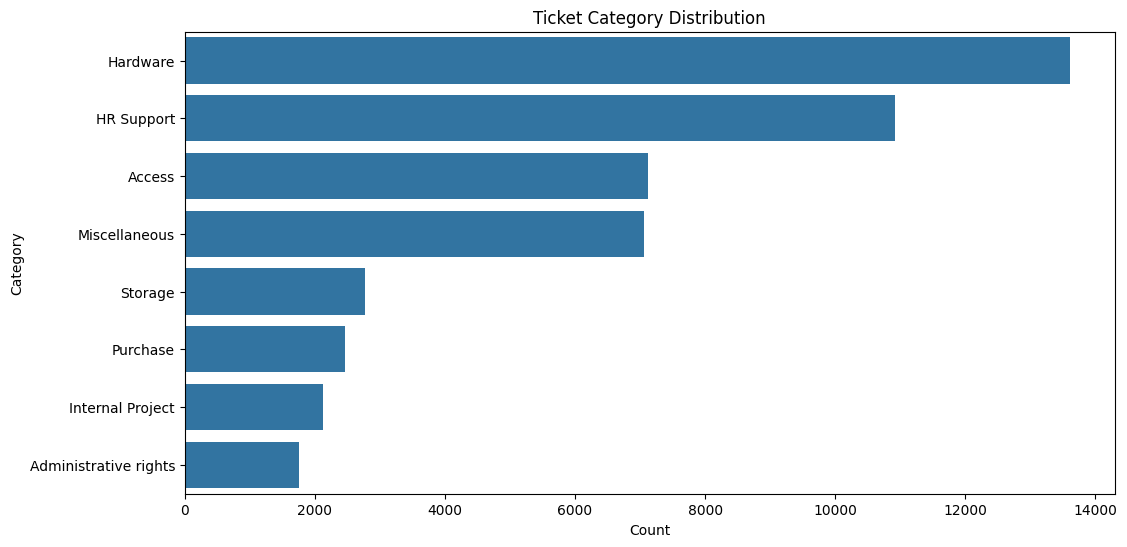

In [10]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df['Topic_group'],
    order=df['Topic_group'].value_counts().index
)

plt.title("Ticket Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

In [15]:
df['text_length'] = df['Document'].apply(len)

Text(0.5, 1.0, 'Text Length Distribution')

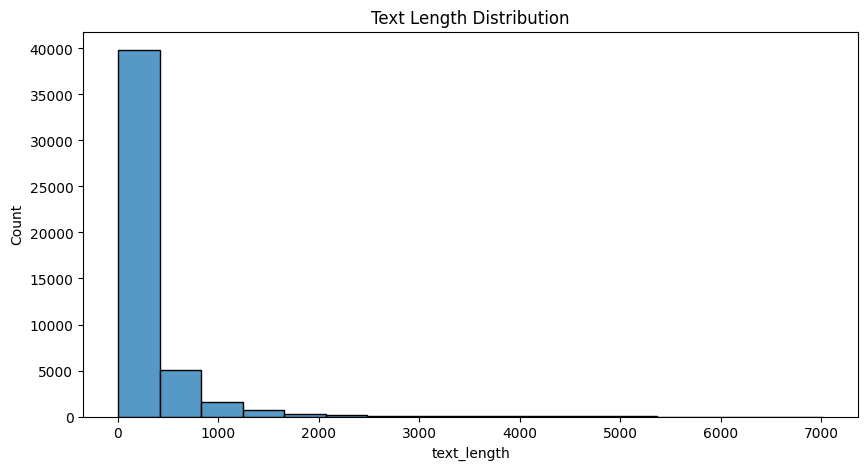

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df['text_length'],bins=17)
plt.title("Text Length Distribution")

In [20]:
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

In [22]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z\s]',' ',text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens=word_tokenize(text)
    tokens=[word for word in tokens if word not in stop_words and len(word)>2]
    tokens=[lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [23]:
df['Cleaned_Text'] = df['Document'].apply(clean_text)

In [27]:
df[['Document','Cleaned_Text']].head()

,Document,Cleaned_Text
0,connection with icon icon dear please setup ic...,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,work experience user work experience user work...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting please h...
3,reset passwords for external accounts re expir...,reset password external account expire day ask...
4,mail verification warning hi has got attached ...,mail verification warning got attached please ...


In [28]:
X = df['Cleaned_Text']
y = df['Topic_group']

In [29]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_vectorized = tfidf.fit_transform(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
svm_model = LinearSVC(
    C=2,
    class_weight='balanced'
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [32]:
print(classification_report(y_pred_svm,y_test))

                       precision    recall  f1-score   support

               Access       0.90      0.88      0.89      1451
Administrative rights       0.74      0.72      0.73       363
           HR Support       0.85      0.87      0.86      2136
             Hardware       0.81      0.83      0.82      2660
     Internal Project       0.88      0.84      0.86       442
        Miscellaneous       0.84      0.80      0.82      1469
             Purchase       0.90      0.90      0.90       491
              Storage       0.89      0.88      0.89       556

             accuracy                           0.85      9568
            macro avg       0.85      0.84      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



In [38]:
print("SVM Accuracy:",accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.845108695652174


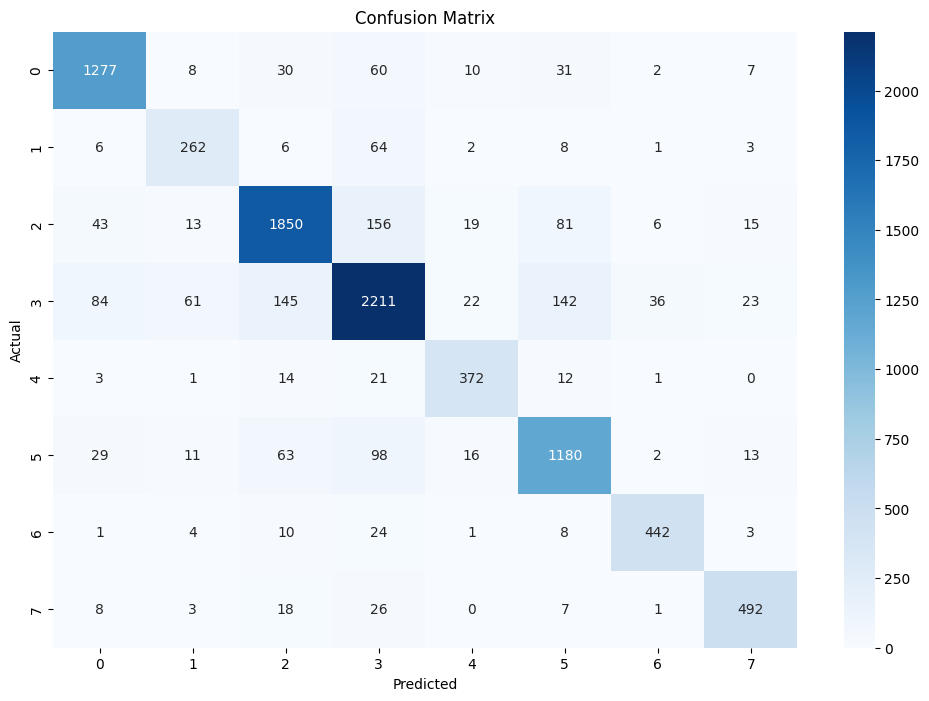

In [39]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
import pickle
pickle.dump(
    svm_model,
    open('ticket_classifier.pkl', 'wb')
)
pickle.dump(
    tfidf,
    open('tfidf_vectorizer.pkl', 'wb')
)

In [52]:
def predict_ticket(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = svm_model.predict(vectorized)
    return prediction[0]

In [53]:
sample = "System crash while processing payment"
predict_ticket(sample)

'Hardware'

In [56]:
def assign_priority(text,topic):
    text=str(text).lower()
    topic=str(topic).lower()
    high_topics=['security', 'system failure', 'network', 'database', 'server']
    medium_topics=['billing','payment','account']
    high_keywords=['urgent', 'critical', 'failed', 'failure', 'crash', 'error', 'unable', 'not working', 'immediately']
    medium_keywords= ['delay','slow','issue','problem','refund']

    if any(word in text for word in high_keywords):
        return 'High'
    if any (topic_word in topic for topic_word in high_topics):
        return 'High'
    if any(word in text for word in medium_keywords):
        return 'Medium'
    if any(topic_word in topic for topic_word in medium_topics):
        return 'Medium'
    return 'Low'

In [57]:
df['Priority'] = df.apply(lambda x:assign_priority(x['Document'],x['Topic_group']),axis=1)

In [58]:
df['Priority'].value_counts()

Priority
Low       33353
High       8299
Medium     6185
Name: count, dtype: int64

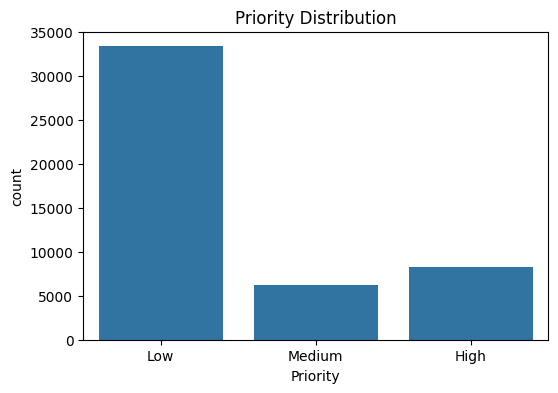

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['Priority'])

plt.title("Priority Distribution")

plt.show()

In [60]:
X_priority = df['Cleaned_Text']
y_priority = df['Priority']

In [61]:
tfidf_priority = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)
X_priority_vectorized = tfidf_priority.fit_transform(X_priority)

In [62]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split( X_priority_vectorized, y_priority, test_size=0.2, random_state=42, stratify=y_priority )

In [63]:
priority_model = LinearSVC(
    C=2,
    class_weight='balanced'
)
priority_model.fit(X_train_p, y_train_p)
y_pred_p = priority_model.predict(X_test_p)

In [64]:
print(classification_report(y_test_p,y_pred_p))

              precision    recall  f1-score   support

        High       0.98      0.94      0.96      1660
         Low       0.98      1.00      0.99      6671
      Medium       0.95      0.92      0.93      1237

    accuracy                           0.98      9568
   macro avg       0.97      0.95      0.96      9568
weighted avg       0.98      0.98      0.98      9568



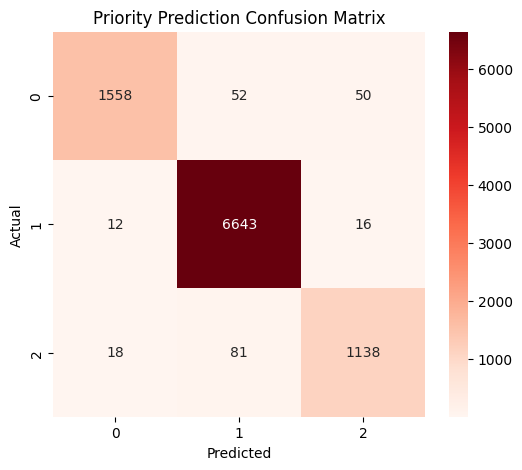

In [65]:
cm = confusion_matrix(y_test_p, y_pred_p)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)
plt.title("Priority Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [66]:
pickle.dump(
    priority_model,
    open('priority_classifier.pkl', 'wb')
)
pickle.dump(
    tfidf_priority,
    open('priority_vectorizer.pkl', 'wb')
)

In [69]:
def predict_priority(text):
    cleaned=clean_text(text)
    vectorized=tfidf_priority.transform([cleaned])
    prediction=priority_model.predict(vectorized)
    return prediction[0]

In [70]:
sample = "Critical server crash causing payment failure"
predict_priority(sample)

'High'